## Import essential libraries to use throughout the project

In [152]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [153]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [154]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5286,ham,I'm still pretty weak today .. Bad day ?,NaN,NaN,NaN
3009,ham,Imagine Life WITHOUT ME... see.. How fast u ar...,NaN,NaN,NaN
2753,ham,"Derp. Which is worse, a dude who always wants ...",NaN,NaN,NaN
3386,ham,So u workin overtime nigpun?,NaN,NaN,NaN
4924,ham,Ok... Let u noe when i leave my house.,NaN,NaN,NaN


In [155]:
df.shape

(5572, 5)

## Data Cleaning

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [157]:
# Drop column 2, 3, 4 since they have very little values that are not NaN.

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [158]:
# Rename the column names

df.rename(columns={'v1': 'target', 'v2':'text_input'}, inplace=True)

In [159]:
df

,target,text_input
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [160]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [161]:
df['target'] = encoder.fit_transform(df['target'])

In [162]:
df.head()

,target,text_input
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [163]:
# Check missing values

df.isnull().sum()

target        0
text_input    0
dtype: int64

In [164]:
# Check duplicate values

df.duplicated().sum()

np.int64(403)

In [165]:
# Remove Duplicates

df = df.drop_duplicates(keep='first')

In [166]:
# Check duplicate values

df.duplicated().sum()

np.int64(0)

In [167]:
df.shape

(5169, 2)

## EDA

In [168]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

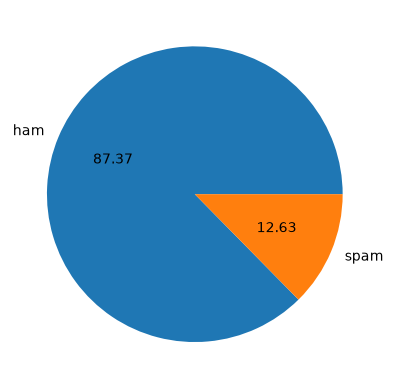

In [169]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")

In [170]:
import ssl
import nltk

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/abhinav/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/abhinav/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [171]:
# Get number of characters in each message

df['char_count'] = df['text_input'].str.len()

In [172]:
df.head()

,target,text_input,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [173]:
# Get number of words in each message

df['word_count'] = df['text_input'].str.split().str.len()

In [174]:
df.head()

,target,text_input,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [175]:
# Get number of sentences in each message

df['sentence_count'] = df['text_input'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [176]:
df.head()

,target,text_input,char_count,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [179]:
df[['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,1.965564
std,58.236293,11.068488,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,7.000000,1.000000
50%,60.000000,12.000000,1.000000
75%,117.000000,22.000000,2.000000
max,910.000000,171.000000,38.000000


## Import essential libraries to use throughout the project

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
5286,ham,I'm still pretty weak today .. Bad day ?,NaN,NaN,NaN
3009,ham,Imagine Life WITHOUT ME... see.. How fast u ar...,NaN,NaN,NaN
2753,ham,"Derp. Which is worse, a dude who always wants ...",NaN,NaN,NaN
3386,ham,So u workin overtime nigpun?,NaN,NaN,NaN
4924,ham,Ok... Let u noe when i leave my house.,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

## Data Cleaning

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [ ]:
# Drop column 2, 3, 4 since they have very little values that are not NaN.

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [ ]:
# Rename the column names

df.rename(columns={'v1': 'target', 'v2':'text_input'}, inplace=True)

In [ ]:
df

,target,text_input
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [ ]:
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
df.head()

,target,text_input
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# Check missing values

df.isnull().sum()

target        0
text_input    0
dtype: int64

In [ ]:
# Check duplicate values

df.duplicated().sum()

np.int64(403)

In [ ]:
# Remove Duplicates

df = df.drop_duplicates(keep='first')

In [ ]:
# Check duplicate values

df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(5169, 2)

## EDA

In [ ]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

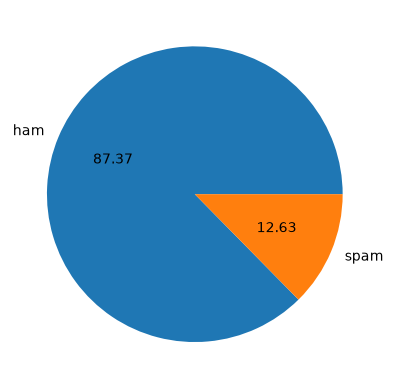

In [ ]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")

In [ ]:
import ssl
import nltk

ssl._create_default_https_context = ssl._create_unverified_context
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /Users/abhinav/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/abhinav/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# Get number of characters in each message

df['char_count'] = df['text_input'].str.len()

In [ ]:
df.head()

,target,text_input,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
# Get number of words in each message

df['word_count'] = df['text_input'].str.split().str.len()

In [ ]:
df.head()

,target,text_input,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20
1,0,Ok lar... Joking wif u oni...,29,6
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28
3,0,U dun say so early hor... U c already then say...,49,11
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13


In [ ]:
# Get number of sentences in each message

df['sentence_count'] = df['text_input'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [ ]:
df.head()

,target,text_input,char_count,word_count,sentence_count
0,0,"Go until jurong point, crazy.. Available only ...",111,20,2
1,0,Ok lar... Joking wif u oni...,29,6,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,28,2
3,0,U dun say so early hor... U c already then say...,49,11,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,13,1


In [180]:
df[['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,15.340685,1.965564
std,58.236293,11.068488,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,7.000000,1.000000
50%,60.000000,12.000000,1.000000
75%,117.000000,22.000000,2.000000
max,910.000000,171.000000,38.000000


In [183]:
# Describe output message for 'ham' messages

df[df['target'] == 0][['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,14.134632,1.820195
std,56.358207,11.116240,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,7.000000,1.000000
50%,52.000000,11.000000,1.000000
75%,90.000000,18.000000,2.000000
max,910.000000,171.000000,38.000000


In [184]:
# Describe output message for 'spam' messages

df[df['target'] == 1][['char_count', 'word_count', 'sentence_count']].describe()

,char_count,word_count,sentence_count
count,653.000000,653.000000,653.000000
mean,137.891271,23.681470,2.970904
std,30.137753,5.967672,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,22.000000,2.000000
50%,149.000000,25.000000,3.000000
75%,157.000000,28.000000,4.000000
max,224.000000,35.000000,9.000000


<Axes: xlabel='char_count', ylabel='Count'>

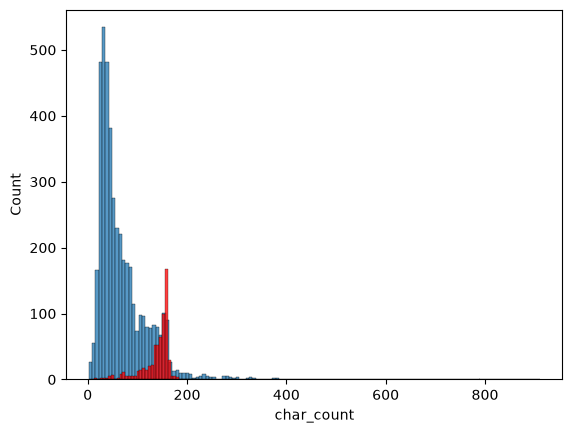

In [188]:
sns.histplot(df[df['target'] == 0]['char_count'])
sns.histplot(df[df['target'] == 1]['char_count'], color='red')

<Axes: xlabel='word_count', ylabel='Count'>

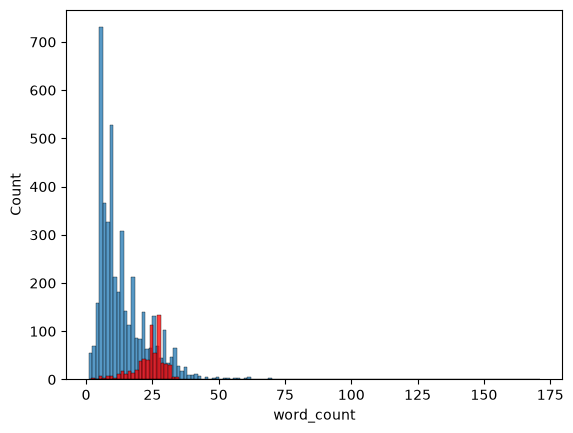

In [189]:
sns.histplot(df[df['target'] == 0]['word_count'])
sns.histplot(df[df['target'] == 1]['word_count'], color='red')

<Axes: xlabel='sentence_count', ylabel='Count'>

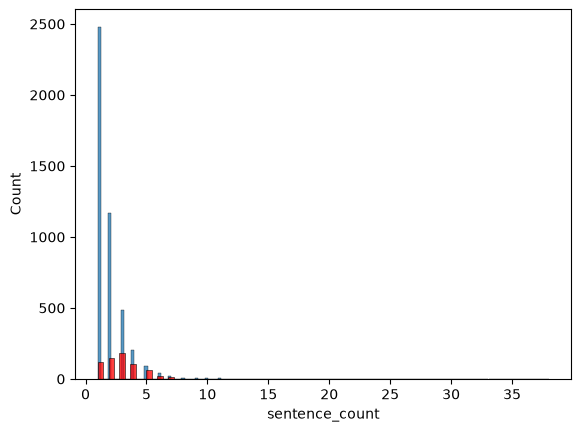

In [190]:
sns.histplot(df[df['target'] == 0]['sentence_count'])
sns.histplot(df[df['target'] == 1]['sentence_count'], color='red')

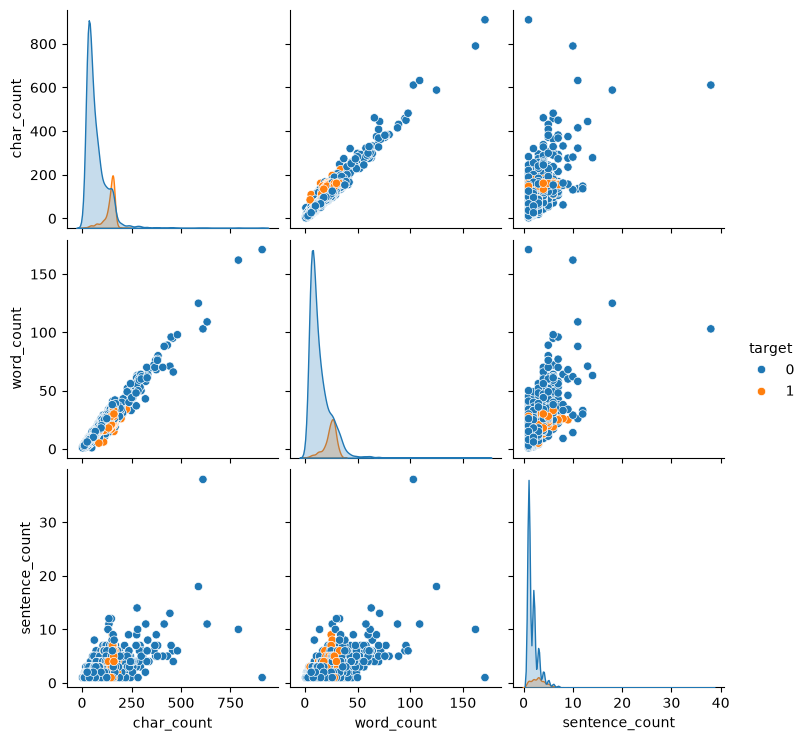

In [191]:
sns.pairplot(df, hue='target')

<Axes: >

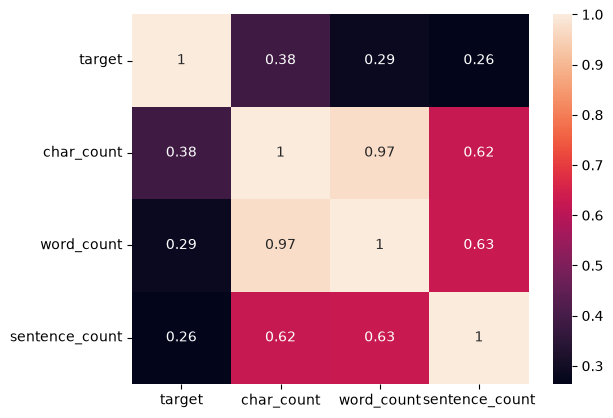

In [195]:
sns.heatmap(df.corr(numeric_only=True), annot=True)